# Metadata exploration

File "hmp2_metadata_2018-08-20.csv" downloaded from https://ibdmdb.org/results

In [1]:
import numpy as np
import pandas as pd 
from pathlib import Path
import matplotlib.pyplot as plt
import os


In [2]:
# Paths setup

# Base path = where the project lives (works in local + Colab if consistent)
base_path = Path.cwd().resolve().parent

print("Current working directory:", base_path)

# Output directory
metadata_dir = base_path / "dataset" / "ibdmdb_hmp2" / "metadata"

# Create folder if it doesn't exist
metadata_dir.mkdir(parents=True, exist_ok=True)

# Change working directory
os.chdir(metadata_dir)

print("Now working in:", os.getcwd())

Current working directory: /Users/hector/git/predictive_microbiology_workshop_UNAM
Now working in: /Users/hector/git/predictive_microbiology_workshop_UNAM/dataset/ibdmdb_hmp2/metadata


In [3]:
# Path to FASTQ files
hmp2_metadata = pd.read_csv(metadata_dir / "hmp2_metadata_2018-08-20.csv", sep=",", low_memory=False)

print(hmp2_metadata.head())


        Project External ID Participant ID site_sub_coll   data_type  \
0  C3001CSC1_BP      206615          C3001     C3001CSC1  biopsy_16S   
1  C3001CSC2_BP      206614          C3001     C3001CSC2  biopsy_16S   
2  C3002CSC1_BP      206617          C3002     C3002CSC1  biopsy_16S   
3  C3002CSC2_BP      206619          C3002     C3002CSC2  biopsy_16S   
4  C3002CSC3_BP      206616          C3002     C3002CSC3  biopsy_16S   

   week_num date_of_receipt  interval_days  visit_num Research Project  ...  \
0       2.0             NaN            NaN          1           ibdmdb  ...   
1       2.0             NaN            NaN          1           ibdmdb  ...   
2       0.0             NaN            NaN          1           ibdmdb  ...   
3       0.0             NaN            NaN          1           ibdmdb  ...   
4       0.0             NaN            NaN          1           ibdmdb  ...   

  FecalCal received at MGH:  Proteomics received at LBNL:  \
0                        No    

In [4]:
# Filter only 16S samples
df_amplicon = hmp2_metadata.query("data_type.str.contains('16S', na=False)").copy()

# Select only relevant columns
df_clean = df_amplicon[['External ID', 'diagnosis', 'biopsy_location']]

# Rename ID column to QIIME2 standard
df_clean = df_clean.rename(columns={'External ID': '#SampleID'})

# Remove missing IDs
df_clean = df_clean.dropna(subset=['#SampleID'])

# Export as TRUE TSV (critical)
df_clean.to_csv(metadata_dir /
    "metadata_test.tsv",
    sep="\t",
    index=False,
    encoding="utf-8"
)

In [5]:
hmp2_metadata['data_type'].unique()

df_amplicon = hmp2_metadata[hmp2_metadata['data_type'] == 'biopsy_16S'] # subset of the metadata with only the 16S amplicon data
print(df_amplicon['data_type'].unique())
print("Number of rows in df_amplicon: ", len(df_amplicon))

['biopsy_16S']
Number of rows in df_amplicon:  178


In [6]:
df_amplicon.columns 

Index(['Project', 'External ID', 'Participant ID', 'site_sub_coll',
       'data_type', 'week_num', 'date_of_receipt', 'interval_days',
       'visit_num', 'Research Project',
       ...
       'FecalCal received at MGH:', 'Proteomics received at LBNL:',
       'Stool Sample ID:  Tube A  (EtOH)',
       'Sample ID: Tube B (No preservative)',
       'Tube A and B received at Broad:', 'stool_id', 'smoking status',
       'Number years smoked', 'Age when started smoking',
       'How many cigarettes/cigars/etc. do you smoke per day?'],
      dtype='object', length=490)

In [7]:
# Rename the 'Participant ID' column to 'sample-id' for compatibility with QIIME2
df_amplicon.rename(columns={'Participant ID': 'sample-id'}, inplace=True)

# save the amplicon metadata as a TSV file for use in QIIME2
df_amplicon.to_csv(metadata_dir / 'hmp2_metadata_2018-08-20_fixed.tsv', sep='\t', index=False)
df = pd.read_csv(metadata_dir / "hmp2_metadata_2018-08-20_fixed.tsv", sep="\t") 

/var/folders/yb/_xf4lxss6n9g0n8frp24vv7w0000gn/T/ipykernel_1979/759316353.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_amplicon.rename(columns={'Participant ID': 'sample-id'}, inplace=True)


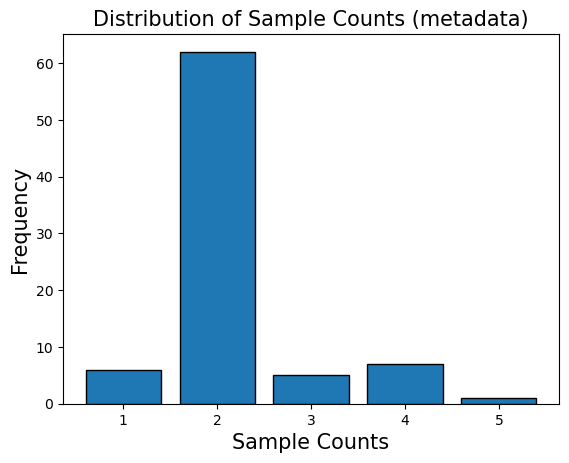

In [8]:
# Check that the 'sample-id' column exists and has the expected number of unique values
counts= df['sample-id'].value_counts()

# Plot histogram 

# Define bins to center on integers
bins = np.arange(min(counts), max(counts) + 2) - 0.5

# 2. Plot with rwidth to add space between bars (optional)
plt.hist(counts, bins=bins, rwidth=0.8, edgecolor='black')
plt.xticks(range(min(counts), max(counts) + 1))
plt.xlabel('Sample Counts', fontsize=15)
plt.ylabel('Frequency', fontsize=15)
plt.title('Distribution of Sample Counts (metadata)', fontsize=15)
plt.savefig(base_path / "figures" / "metadata_sample_counts_histogram.png", dpi=300, bbox_inches='tight')
plt.show()